# Pretrained VGG16 기반 U-Net 실습

해당 프로젝트에서는 Giana(Polyp) 데이터셋을 이용해 아래 과정을 수행합니다.

1. **라이브러리 로딩 및 버전 확인**
2. **STEP 1 : 데이터셋 구성**

3. **STEP 2 : pretrained model(VGG16) 활용한 U-Net 모델 구성**

4. **STEP 3 : 학습 및 테스트, 시각화**

5. **STEP 4 : 모델 성능 비교분석**


## 1. 라이브러리 로딩 및 버전 확인

현재 사용하는 라이브러리들을 로딩하고 일부 라이브러리의 버전을 체크해봅니다.


In [29]:
# 필요 라이브러리 로딩
from __future__ import absolute_import, division
from __future__ import print_function, unicode_literals

import os
import time
import shutil
import functools

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['axes.grid'] = False
mpl.rcParams['figure.figsize'] = (12,12)

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.image as mpimg
import pandas as pd
from PIL import Image
from IPython.display import clear_output

import tensorflow as tf
import tensorflow_addons as tfa
print(tf.__version__)

from tensorflow.keras import layers
from tensorflow.keras import losses
from tensorflow.keras import models

2.13.0


## 2. STEP 1 : 데이터셋 구성

여기서는 Giana Polyp 데이터셋을 예시로 사용합니다.

1. `x_train_filenames`, `y_train_filenames`로 이미지/마스크 경로를 각각 수집하고 정렬

2. `train_test_split`을 이용해 훈련/테스트를 8:2로 분할
3. `tf.data.Dataset` + `map()`을 통해 augmentation 및 배치처리.


Number of training examples: 240
Number of test examples:	 60


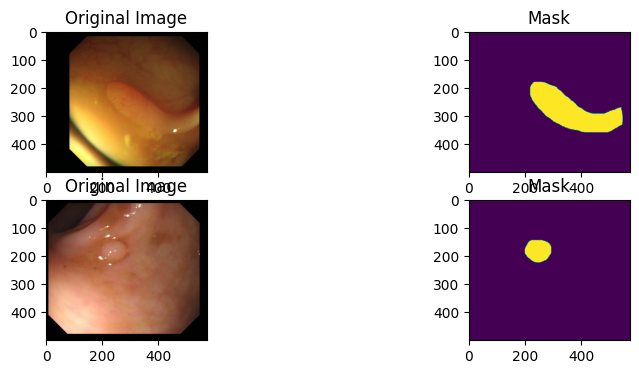

In [30]:
# 데이터셋 경로 (폴더 구조에 맞게 수정)
DATASET_PATH = "/Users/dataliteracy/programming/AI/AIFFEL/ai_app_project/assets/polyp/giana"  # 예시

# Giana 데이터셋 구조 예:
# /giana
#   |- train
#   |- train_labels

img_dir = os.path.join(DATASET_PATH, "train")
label_dir = os.path.join(DATASET_PATH, "train_labels")

x_train_filenames = [os.path.join(img_dir, fname) for fname in os.listdir(img_dir)]
y_train_filenames = [os.path.join(label_dir, fname) for fname in os.listdir(label_dir)]

x_train_filenames.sort()
y_train_filenames.sort()

# 훈련/테스트 분할
x_train_filenames, x_test_filenames, y_train_filenames, y_test_filenames = train_test_split(x_train_filenames,
                                                                                            y_train_filenames,
                                                                                            test_size=0.2,
                                                                                            random_state=42)

num_train_examples = len(x_train_filenames)
num_test_examples = len(x_test_filenames)
print("Number of training examples:", num_train_examples)
print("Number of test examples:\t", num_test_examples)

# 하이퍼파라미터 설정
image_size = 256  # 원하는 크기로 조절
img_shape = (image_size, image_size, 3)
batch_size = 8
max_epochs = 10

# (옵션) 확인용 시각화
def display_samples(n=3):
    plt.figure(figsize=(10, 2*n))
    r_choices = np.random.choice(num_train_examples, n)
    for i in range(n):
        idx = r_choices[i]
        x_path, y_path = x_train_filenames[idx], y_train_filenames[idx]
        plt.subplot(n, 2, 2*i+1)
        plt.imshow(Image.open(x_path))
        plt.title("Original Image")
        
        plt.subplot(n, 2, 2*i+2)
        plt.imshow(Image.open(y_path))
        plt.title("Mask")
    plt.show()

display_samples(n=2)

### tf.data 파이프라인 구성

1. `_process_pathnames`: 경로로부터 이미지/마스크를 읽고, 리사이즈, `[0,1]`로 스케일링.

2. `shift_img`, `flip_img`, `_augment`: 증강 함수를 합쳐둔 보조함수들.
3. `get_baseline_dataset`: `tf.data.Dataset.from_tensor_slices`로 (이미지, 라벨) 튜플을 만들고, `map`으로 전처리.

   - 훈련용(`is_train=True`)인 경우 셔플 + 증강.

   - 테스트용(`is_train=False`)인 경우 단순 전처리만.


In [31]:
def _process_pathnames(fname, label_path):
    img_str = tf.io.read_file(fname)
    img = tf.image.decode_bmp(img_str, channels=3)

    label_img_str = tf.io.read_file(label_path)
    label_img = tf.image.decode_bmp(label_img_str, channels=3)
    label_img = tf.image.rgb_to_grayscale(label_img)

    resize = [image_size, image_size]
    img = tf.image.resize(img, resize)
    label_img = tf.image.resize(label_img, resize)

    scale = 1 / 255.
    img = tf.cast(img, dtype=tf.float32) * scale
    label_img = tf.cast(label_img, dtype=tf.float32) * scale

    return img, label_img

def shift_img(output_img, label_img, width_shift_range, height_shift_range):
    if width_shift_range or height_shift_range:
        if width_shift_range:
            width_shift_range = tf.random.uniform([],
                                                  -width_shift_range * image_size,
                                                   width_shift_range * image_size)
        if height_shift_range:
            height_shift_range = tf.random.uniform([],
                                                   -height_shift_range * image_size,
                                                    height_shift_range * image_size)
        output_img = tfa.image.translate(output_img,
                                         [width_shift_range, height_shift_range])
        label_img = tfa.image.translate(label_img,
                                        [width_shift_range, height_shift_range])
    return output_img, label_img

def flip_img(horizontal_flip, tr_img, label_img):
    if horizontal_flip:
        flip_prob = tf.random.uniform([], 0.0, 1.0)
        tr_img, label_img = tf.cond(tf.less(flip_prob, 0.5),
                                    lambda: (tf.image.flip_left_right(tr_img), tf.image.flip_left_right(label_img)),
                                    lambda: (tr_img, label_img))
    return tr_img, label_img

def _augment(img,
             label_img,
             resize=None,
             scale=1,
             hue_delta=0.,
             horizontal_flip=True,
             width_shift_range=0.05,
             height_shift_range=0.05):

    if resize is not None:
        label_img = tf.image.resize(label_img, resize)
        img = tf.image.resize(img, resize)

    if hue_delta:
        img = tf.image.random_hue(img, hue_delta)

    img, label_img = flip_img(horizontal_flip, img, label_img)
    img, label_img = shift_img(img, label_img, width_shift_range, height_shift_range)

    label_img = tf.cast(label_img, dtype=tf.float32) * scale
    img = tf.cast(img, dtype=tf.float32) * scale

    return img, label_img

import functools

def get_baseline_dataset(filenames,
                         labels,
                         preproc_fn=functools.partial(_augment),
                         threads=4,
                         batch_size=batch_size,
                         is_train=True):
    num_x = len(filenames)
    dataset = tf.data.Dataset.from_tensor_slices((filenames, labels))
    dataset = dataset.map(_process_pathnames, num_parallel_calls=threads)

    if is_train:
        dataset = dataset.map(preproc_fn, num_parallel_calls=threads)
        dataset = dataset.shuffle(num_x * 10)

    dataset = dataset.batch(batch_size)
    return dataset

# 최종적으로 train_dataset, test_dataset 생성
train_dataset = get_baseline_dataset(x_train_filenames,
                                     y_train_filenames,
                                     is_train=True)
train_dataset = train_dataset.repeat()  # 무한 반복

test_dataset = get_baseline_dataset(x_test_filenames,
                                    y_test_filenames,
                                    is_train=False)

print(train_dataset, test_dataset)

<_RepeatDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))> <_BatchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>


### 샘플 배치 확인

학습 데이터셋에서 배치 하나를 불러와서, 이미지와 라벨이 정상적으로 매핑되는지 확인합니다.


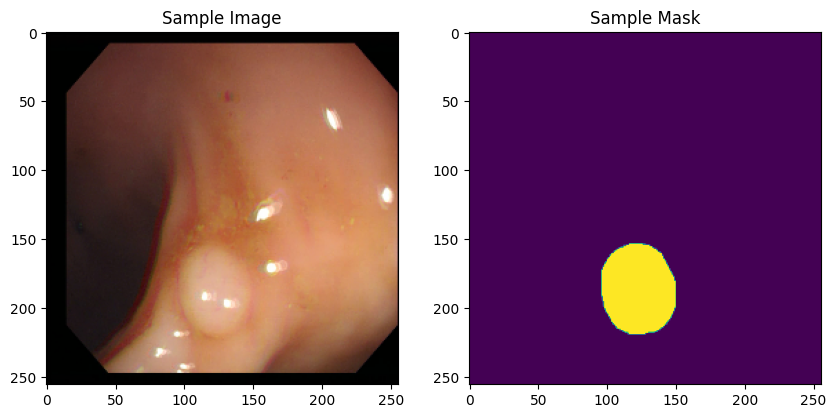

In [32]:
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    img = images[0]

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Sample Image")

    plt.subplot(1, 2, 2)
    plt.imshow(labels[0, :, :, 0])
    plt.title("Sample Mask")
    plt.show()

## 3. STEP 2: pretrained model(VGG16) 활용한 U-Net 모델 구성

VGG16(또는 다른 모델)을 **Encoder**로 활용하고, Decoder는 U-Net 방식으로 구성.

먼저, U-Net에서 활용할 Conv 블록들을 재정의합니다.

- `Conv` : Conv2D + BatchNorm + ReLU

- `ConvBlock` : 두 번의 Conv

- `DecoderBlock` : ConvTranspose로 업샘플 후 skip connection concat → 다시 ConvBlock


In [33]:
from tensorflow.keras import layers, models

class Conv(tf.keras.Model):
    def __init__(self, num_filters, kernel_size):
        super(Conv, self).__init__()
        self.conv = layers.Conv2D(num_filters, kernel_size, padding='same')
        self.bn = layers.BatchNormalization()

    def call(self, inputs, training=True):
        x = self.conv(inputs)
        x = self.bn(x, training=training)
        x = tf.nn.relu(x)
        return x

class ConvBlock(tf.keras.Model):
    def __init__(self, num_filters):
        super(ConvBlock, self).__init__()
        self.conv1 = Conv(num_filters, 3)
        self.conv2 = Conv(num_filters, 3)

    def call(self, inputs, training=True):
        x = self.conv1(inputs, training=training)
        x = self.conv2(x, training=training)
        return x

class DecoderBlock(tf.keras.Model):
    def __init__(self, num_filters):
        super(DecoderBlock, self).__init__()
        self.convT = layers.Conv2DTranspose(num_filters, 3, strides=2, padding='same')
        self.bn = layers.BatchNormalization()
        self.conv_block = ConvBlock(num_filters)

    def call(self, input_tensor, concat_tensor, training=True):
        x = self.convT(input_tensor)
        x = self.bn(x, training=training)
        x = tf.nn.relu(x)
        x = tf.concat([x, concat_tensor], axis=-1)  # skip connection
        x = self.conv_block(x, training=training)
        return x

### VGG16 인코더의 레이어 구조

U-Net은 Encoder 각 단계의 출력을 Decoder로 skip 연결해야 합니다.

VGG16의 레이어를 출력해 보면 (layer_outputs)에서 우리가 필요한 시점의 feature map을 확인할 수 있습니다.

```
Block1 → (layer_outputs[2])
Block2 → (layer_outputs[5])
Block3 → (layer_outputs[9])
Block4 → (layer_outputs[13])
Block5 → (layer_outputs[17])
```

이 5개 feature map을 Decoder 단계에서 순차적으로 concat하여 사용할 예정입니다.


In [34]:
vgg16 = tf.keras.applications.VGG16(input_shape=img_shape,
                                   include_top=False,
                                   weights='imagenet')

layer_outputs = [layer.output for layer in vgg16.layers]
print("레이어 개수:", len(layer_outputs))
print("예: 0번째 레이어 shape:", layer_outputs[0].shape)
print("마지막(블록5) 레이어 shape:", layer_outputs[17].shape)

레이어 개수: 19
예: 0번째 레이어 shape: (None, 256, 256, 3)
마지막(블록5) 레이어 shape: (None, 16, 16, 512)


### VGG16을 Encoder로 활용한 U-Net 구현


In [35]:
class Vgg16UNet(tf.keras.Model):
    def __init__(self):
        super(Vgg16UNet, self).__init__()
        # VGG16 pretrained
        self.vgg16 = tf.keras.applications.VGG16(input_shape=img_shape,
                                               include_top=False,
                                               weights='imagenet')
        # 필요한 5개 레이어 출력을 뽑아내도록 서브모델 구성
        layer_outputs = [layer.output for layer in self.vgg16.layers]

        # 인덱스:
        # Block1 conv2 : layer_outputs[2]
        # Block2 conv2 : layer_outputs[5]
        # Block3 conv3 : layer_outputs[9]
        # Block4 conv3 : layer_outputs[13]
        # Block5 conv3 : layer_outputs[17]

        self.vgg16_act = models.Model(inputs=self.vgg16.input, 
                                      outputs=[layer_outputs[2], 
                                               layer_outputs[5], 
                                               layer_outputs[9], 
                                               layer_outputs[13], 
                                               layer_outputs[17]])

        # Decoder 부분
        self.decoder_block4 = DecoderBlock(512)
        self.decoder_block3 = DecoderBlock(256)
        self.decoder_block2 = DecoderBlock(128)
        self.decoder_block1 = DecoderBlock(64)

        self.output_conv = layers.Conv2D(1, 1, activation='sigmoid')

    def call(self, inputs, training=True):
        # encoder1 ~ center에 해당하는 5개 feature map을 뽑음
        encoder1, encoder2, encoder3, encoder4, center = self.vgg16_act(inputs)

        # decoder 블록 (U-Net skip connection)
        # center(=block5) up + skip(=block4)
        decoder4 = self.decoder_block4(center, encoder4, training=training)
        # decoder4 up + skip(=block3)
        decoder3 = self.decoder_block3(decoder4, encoder3, training=training)
        # decoder3 up + skip(=block2)
        decoder2 = self.decoder_block2(decoder3, encoder2, training=training)
        # decoder2 up + skip(=block1)
        decoder1 = self.decoder_block1(decoder2, encoder1, training=training)

        outputs = self.output_conv(decoder1)
        return outputs

## 4. STEP 3: 학습 및 테스트, 시각화

### 4.1 모델 생성 및 컴파일

- `bce_dice_loss` 같은 세그멘테이션용 커스텀 로스를 사용합니다.

- 옵티마이저, 메트릭 등을 설정합니다.


In [36]:
def dice_coeff(y_true, y_pred):
    smooth = 1e-10
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    score = (2. * intersection + smooth) / (tf.reduce_sum(tf.square(y_true_f)) + tf.reduce_sum(tf.square(y_pred_f)) + smooth)
    return score

def dice_loss(y_true, y_pred):
    loss = 1 - dice_coeff(y_true, y_pred)
    return loss

def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(losses.binary_crossentropy(y_true, y_pred))
    d_loss = dice_loss(y_true, y_pred)
    return bce + d_loss

model = Vgg16UNet()
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss=bce_dice_loss,
              metrics=[dice_loss])

# 더미 텐서로 모델 동작 테스트
temp_x = tf.random.normal([batch_size, image_size, image_size, 3])
temp_y = model(temp_x)
print("테스트 출력 shape:", temp_y.shape)

model.summary()

테스트 출력 shape: (8, 256, 256, 1)
Model: "vgg16u_net_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 8, 8, 512)         14714688  
                                                                 
 model_2 (Functional)        [(None, 256, 256, 64),    14714688  
                              (None, 128, 128, 128),             
                              (None, 64, 64, 256),               
                              (None, 32, 32, 512),               
                              (None, 16, 16, 512)]               
                                                                 
 decoder_block_8 (DecoderBl  multiple                  9444864   
 ock)                                                            
                                                                 
 decoder_block_9 (DecoderBl  multiple                  2952960   
 ock)                  

### 4.2 콜백 설정 (체크포인트, 학습률 스케줄 등)

콜백을 통해 모델 가중치를 저장해두고, 혹은 학습률 스케줄링을 해볼 수 있습니다.

실습 편의를 위해 저장 폴더를 하나 만들어 둡니다.


In [37]:
checkpoint_dir = os.path.join(DATASET_PATH, 'train_ckpt', 'vgg16_unet')
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir),
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True,
    verbose=1
)

cos_decay = tf.keras.experimental.CosineDecay(1e-4, max_epochs)
lr_callback = tf.keras.callbacks.LearningRateScheduler(cos_decay, verbose=1)

### 4.3 모델 학습


In [38]:
steps_per_epoch = num_train_examples // batch_size
val_steps = num_test_examples // batch_size

history = model.fit(
    train_dataset,
    epochs=max_epochs,
    steps_per_epoch=steps_per_epoch,
    validation_data=test_dataset,
    validation_steps=val_steps,
    callbacks=[cp_callback, lr_callback]
)


Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/10
30/30 [==============================] - ETA: 0s - loss: 1.1499 - dice_loss: 0.6943
Epoch 1: val_loss improved from inf to 1.03099, saving model to /Users/dataliteracy/programming/AI/AIFFEL/ai_app_project/assets/polyp/giana/train_ckpt/vgg16_unet
30/30 [==============================] - 167s 6s/step - loss: 1.1499 - dice_loss: 0.6943 - val_loss: 1.0310 - val_dice_loss: 0.7363 - lr: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.75528237177059e-05.
Epoch 2/10
30/30 [==============================] - ETA: 0s - loss: 0.6604 - dice_loss: 0.4104
Epoch 2: val_loss did not improve from 1.03099
30/30 [==============================] - 179s 6s/step - loss: 0.6604 - dice_loss: 0.4104 - val_loss: 1.1963 - val_dice_loss: 0.6696 - lr: 9.7553e-05

Epoch 3: LearningRateScheduler setting learning rate to 9.045084152603522e-05.
Epoch 3/10
30/30 [==============================] - ETA: 0s - lo

### 4.4 간단 테스트(시각화)

학습된 모델을 이용하여 테스트 데이터셋에 대한 예측 마스크를 확인해봅시다.


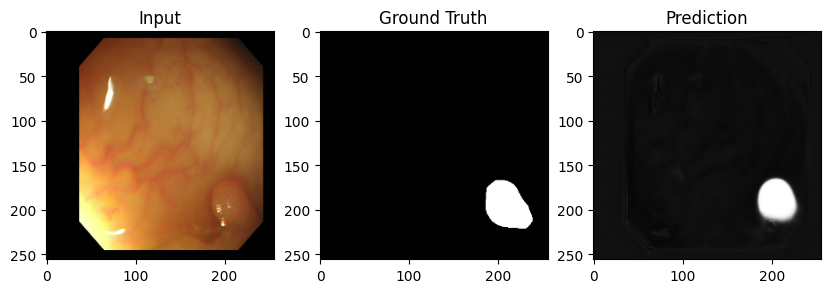

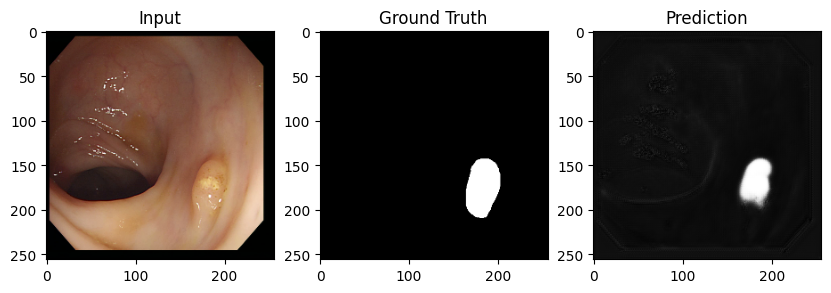

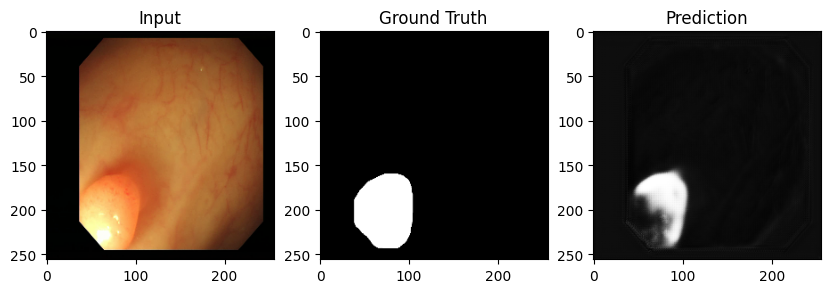

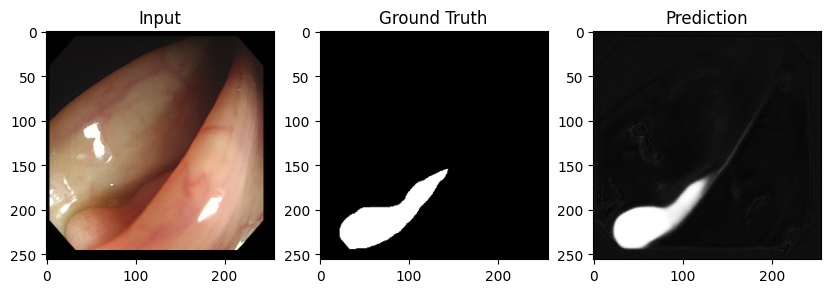

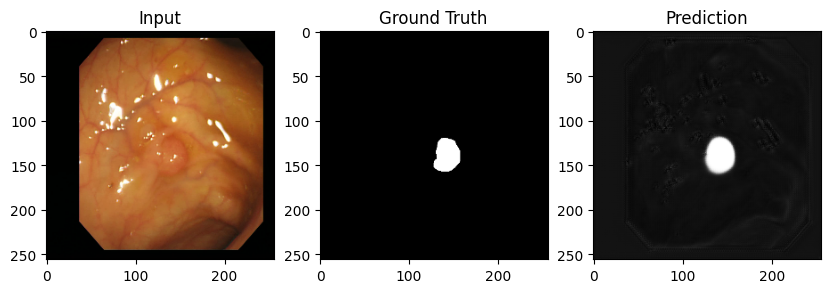

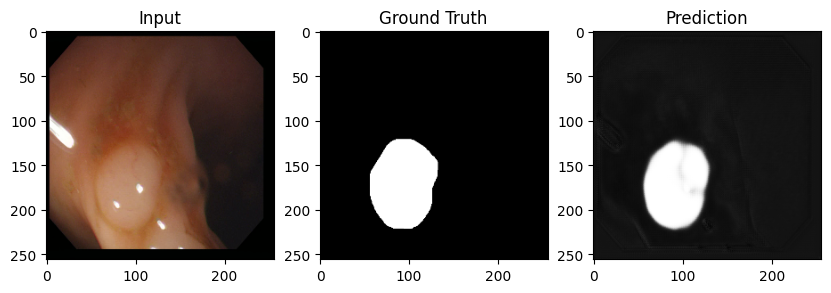

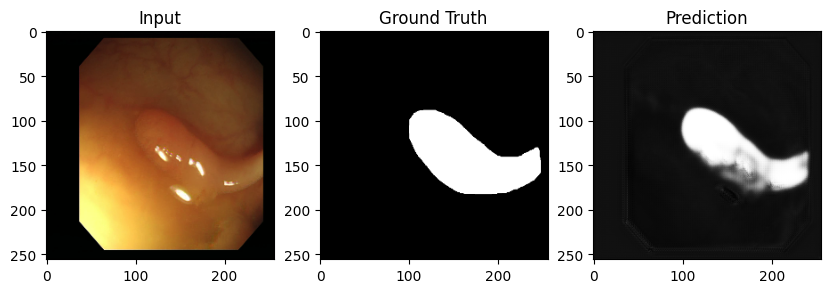

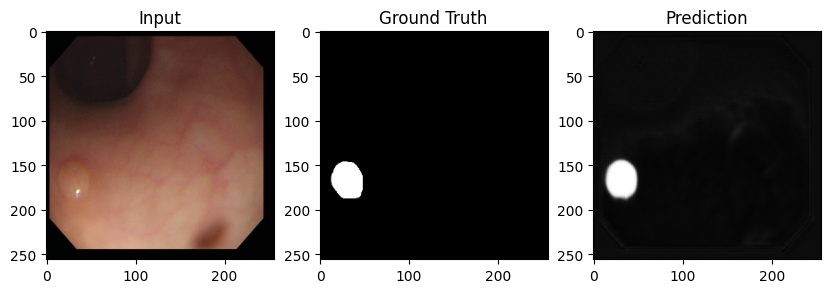

In [ ]:
def visualize_predictions(dataset, model, n=1):
    # n개의 배치를 순회하면서 시각화
    count = 0
    for images, labels in dataset.take(n):
        preds = model(images, training=False)
        batch_size_curr = images.shape[0]
        for i in range(batch_size_curr):
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 3, 1)
            plt.imshow(images[i])
            plt.title("Input")

            plt.subplot(1, 3, 2)
            plt.imshow(labels[i, :, :, 0], cmap='gray')
            plt.title("Ground Truth")

            plt.subplot(1, 3, 3)
            plt.imshow(preds[i, :, :, 0], cmap='gray')
            plt.title("Prediction")

            plt.show()
        count += 1
        if count >= n:
            break

# 저장된 best weight가 있다면 불러오기(선택)
best_weights_path = os.path.join(checkpoint_dir)
if os.path.exists(best_weights_path):
    model.load_weights(best_weights_path)
    print("Best weights loaded.")

# 시각화
visualize_predictions(test_dataset, model, n=1)

## 5. STEP 4: 모델 성능 비교분석

### 5.1 정량 지표 (Mean IoU)

아래 코드는 간단히 **Mean IoU**를 계산하는 함수입니다.
실제로는 TensorFlow 내장 `tf.keras.metrics.MeanIoU`를 써도 됩니다만, 여기선 confusion matrix 방식을 예시로 보여드립니다.

`model` 자리에 **Encoder-Decoder**나 **일반 U-Net**을 각각 학습시킨 모델을 넣어서 결과를 비교해보시면 됩니다.


In [ ]:
def mean_iou(y_true, y_pred, num_classes=2):
    # Flatten
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    # 0.5 기준으로 binary
    y_true_f = tf.cast(tf.round(y_true_f), dtype=tf.int32).numpy()
    y_pred_f = tf.cast(tf.round(y_pred_f), dtype=tf.int32).numpy()

    labels = list(range(num_classes))
    current = confusion_matrix(y_true_f, y_pred_f, labels=labels)

    intersection = np.diag(current)
    ground_truth_set = current.sum(axis=1)
    predicted_set = current.sum(axis=0)
    union = ground_truth_set + predicted_set - intersection
    IoU = intersection / union.astype(np.float32)
    return np.mean(IoU)

[VGG16 U-Net] Mean IoU on Test Dataset: 0.8512389073663564


### 5.2 Encoder-Decoder vs U-Net vs Pretrained U-Net

앞선 노트북(또는 코드)에서 학습한 **Encoder-Decoder 모델**이나 **일반 U-Net**의 가중치를 불러와서 같은 테스트 세트로 IoU를 측정하면 아래처럼 비교할 수 있습니다.

```
# 예시: ED 모델
ed_model = ed_model  # 가정
ed_model.load_weights("/path/to/ed_model")
ed_iou = evaluate_mean_iou(ed_model, test_dataset)

# 예시: 일반 U-Net
unet_model = UNet() # 기존에 정의한 U-Net
unet_model.load_weights("/path/to/unet")
unet_iou = evaluate_mean_iou(unet_model, test_dataset)

print("ED model IoU:", ed_iou)
print("U-Net IoU:\t", unet_iou)
print("VGG16 U-Net IoU:", mean_iou_score)  # 방금 구한 값
```


#### ED 모델 & UNET 모델 가져오기


In [46]:
# inputs: [batch_size, 256, 256, 3]
encoder = tf.keras.Sequential(name='encoder')

# conv-batchnorm-activation-maxpool
encoder.add(layers.Conv2D(64, (3, 3), padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu'))
encoder.add(layers.Conv2D(64, (3, 3), strides=2, padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu')) # conv1: [batch_size, 128, 128, 64]

encoder.add(layers.Conv2D(128, (3, 3), padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu'))
encoder.add(layers.Conv2D(128, (3, 3), strides=2, padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu')) # conv2: [batch_size, 64, 64, 128]

encoder.add(layers.Conv2D(256, (3, 3), padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu'))
encoder.add(layers.Conv2D(256, (3, 3), strides=2, padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu')) # conv3: [batch_size, 32, 32, 256]

encoder.add(layers.Conv2D(512, (3, 3), padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu'))
encoder.add(layers.Conv2D(512, (3, 3), strides=2, padding='same'))
encoder.add(layers.BatchNormalization())
encoder.add(layers.Activation('relu')) # conv4-outputs: [batch_size, 16, 16, 512]

In [47]:
# Encoder 제대로 만들어졌는지 확인

bottleneck = encoder(tf.random.normal([batch_size, 256, 256, 3]))
print(bottleneck.shape)   # (batch_size, 16, 16, 512) 이 나오는지 확인

(8, 16, 16, 512)


##### Decoder


In [48]:
# inputs: [batch_size, 16, 16, 512]
decoder = tf.keras.Sequential(name='decoder')

# conv_transpose-batchnorm-activation
decoder.add(layers.Conv2DTranspose(256, (3, 3), strides=2, padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu')) # conv_transpose1: [batch_size, 32, 32, 256]
decoder.add(layers.Conv2D(256, (3, 3), padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu'))

decoder.add(layers.Conv2DTranspose(128, (3, 3), strides=2, padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu')) # conv_transpose2: [batch_size, 64, 64, 128]
decoder.add(layers.Conv2D(128, (3, 3), padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu'))

decoder.add(layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu')) # conv_transpose3: [batch_size, 128, 128, 64]
decoder.add(layers.Conv2D(64, (3, 3), padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu'))

decoder.add(layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu')) # conv transpose4-outputs: [batch_size, 256, 256, 32]
decoder.add(layers.Conv2D(32, (3, 3), padding='same'))
decoder.add(layers.BatchNormalization())
decoder.add(layers.Activation('relu'))

decoder.add(layers.Conv2DTranspose(1, 1, strides=1, padding='same', activation='sigmoid'))

In [49]:
# decoder 제대로 만들어졌는지 확인

predictions = decoder(bottleneck)
print(predictions.shape)    # (batch_size, 256, 256, 1) 이 나오는지 확인

(8, 256, 256, 1)


In [50]:
ed_model = tf.keras.Sequential()

ed_model.add(encoder)
ed_model.add(decoder)

#### U-Net architecture


##### subclassing 활용


In [51]:
class Conv(tf.keras.Model):
    def __init__(self, num_filters, kernel_size):
        super(Conv, self).__init__()
        self.conv = layers.Conv2D(num_filters, kernel_size, padding='same')
        self.bn = layers.BatchNormalization()

    def call(self, inputs, training=True):
        x = self.conv(inputs)
        x = self.bn(x, training=training)
        x = layers.ReLU()(x)

        return x

In [52]:
class ConvBlock(tf.keras.Model):
    def __init__(self, num_filters):
        super(ConvBlock, self).__init__()
        self.conv1 = Conv(num_filters, 3)
        self.conv2 = Conv(num_filters * 2, 3)

    def call(self, inputs, training=True):
        encoder = self.conv1(inputs, training=training)
        encoder = self.conv2(encoder, training=training)

        return encoder

class ConvBlock_R(tf.keras.Model):
    def __init__(self, num_filters):
        super(ConvBlock_R, self).__init__()
        self.conv1 = Conv(num_filters, 3)
        self.conv2 = Conv(num_filters, 3)

    def call(self, inputs, training=True):
        decoder = self.conv1(inputs, training=training)
        decoder = self.conv2(decoder, training=training)

        return decoder


class EncoderBlock(tf.keras.Model):
    def __init__(self, num_filters):
        super(EncoderBlock, self).__init__()
        self.conv_block = ConvBlock(num_filters)
        self.encoder_pool = layers.MaxPool2D()

    def call(self, inputs, training=True):
        encoder = self.conv_block(inputs, training=training)
        encoder_pool = self.encoder_pool(encoder)

        return encoder_pool, encoder


class DecoderBlock(tf.keras.Model):
    def __init__(self, num_filters):
        super(DecoderBlock, self).__init__()
        self.convT = layers.Conv2DTranspose(num_filters, 3, strides=2, padding='same')
        self.bn = layers.BatchNormalization()
        self.conv_block_r = ConvBlock_R(num_filters)

    def call(self, input_tensor, concat_tensor, training=True):
        decoder = self.convT(input_tensor)
        decoder = self.bn(decoder, training=training)
        decoder = layers.ReLU()(decoder)
        decoder = tf.concat([decoder, concat_tensor], axis=-1)
        decoder = self.conv_block_r(decoder, training=training)

        return decoder

In [53]:
class UNet(tf.keras.Model):
    def __init__(self):
        super(UNet, self).__init__()
        self.encoder_block1 = EncoderBlock(64)
        self.encoder_block2 = EncoderBlock(128)
        self.encoder_block3 = EncoderBlock(256)
        self.encoder_block4 = EncoderBlock(512)

        self.center = ConvBlock(1024)

        self.decoder_block4 = DecoderBlock(512)
        self.decoder_block3 = DecoderBlock(256)
        self.decoder_block2 = DecoderBlock(128)
        self.decoder_block1 = DecoderBlock(64)

        self.output_conv = layers.Conv2D(1, 1, activation='sigmoid')

    def call(self, inputs, training=True):
        encoder1_pool, encoder1 = self.encoder_block1(inputs)
        encoder2_pool, encoder2 = self.encoder_block2(encoder1_pool)
        encoder3_pool, encoder3 = self.encoder_block3(encoder2_pool)
        encoder4_pool, encoder4 = self.encoder_block4(encoder3_pool)

        center = self.center(encoder4_pool)

        decoder4 = self.decoder_block4(center, encoder4)
        decoder3 = self.decoder_block3(decoder4, encoder3)
        decoder2 = self.decoder_block2(decoder3, encoder2)
        decoder1 = self.decoder_block1(decoder2, encoder1)

        outputs = self.output_conv(decoder1)

        return outputs

In [54]:
unet_model = UNet()

In [41]:
def evaluate_mean_iou(model, dataset):
    iou_scores = []
    for images, labels in dataset:
        preds = model(images, training=False)
        score = mean_iou(labels, preds, num_classes=2)
        iou_scores.append(score)
    return np.mean(iou_scores)

In [57]:
checkpoint_dir = "/Users/dataliteracy/programming/AI/AIFFEL/ai_app_project/assets/polyp/giana/train_ckpt"

ed_model_path = tf.train.latest_checkpoint(checkpoint_dir + "/ed_model")
unet_model_path = tf.train.latest_checkpoint(checkpoint_dir + "/unet_model")
vgg16_unet_model_path = tf.train.latest_checkpoint(checkpoint_dir + "/vgg16_unet")

ed_model.load_weights(ed_model_path)
unet_model.load_weights(unet_model_path)
model.load_weights(vgg16_unet_model_path)

ed_model_mean_iou_score = evaluate_mean_iou(ed_model, test_dataset)
unet_model_mean_iou_score = evaluate_mean_iou(unet_model, test_dataset)
vgg16_unet_model_mean_iou_score = evaluate_mean_iou(model, test_dataset)

print("[ED_MODEL] Mean IoU on Test Dataset:", ed_model_mean_iou_score)
print("[UNET_MODEL] Mean IoU on Test Dataset:", unet_model_mean_iou_score)
print("[VGG16_UNET_MODEL] Mean IoU on Test Dataset:", vgg16_unet_model_mean_iou_score)

[ED_MODEL] Mean IoU on Test Dataset: 0.479493909114746
[UNET_MODEL] Mean IoU on Test Dataset: 0.5136323436733286
[VGG16_UNET_MODEL] Mean IoU on Test Dataset: 0.8512389073663564


In [58]:
def print_images(test_dataset, ed_model, unet_model, vgg16_unet_model, batch_size=8):
    """
    test_dataset에서 1개 배치를 꺼내,
    (원본, 실제 마스크, ED 모델 예측, U-Net 모델 예측, VGG16 U-Net 모델 예측)를 
    가로로 5개 subplot으로 시각화합니다.
    """
    for test_images, test_labels in test_dataset.take(1):
        # 세 모델 각각 예측
        ed_preds = ed_model(test_images, training=False)
        unet_preds = unet_model(test_images, training=False)
        vgg16_unet_preds = vgg16_unet_model(test_images, training=False)

        for i in range(batch_size):
            plt.figure(figsize=(20, 4))  # 가로 넓게 (원하시면 조절)
            
            # (1) 원본 이미지
            plt.subplot(1, 5, 1)
            plt.imshow(test_images[i])
            plt.title("Input Image")

            # (2) 실제 마스크
            plt.subplot(1, 5, 2)
            plt.imshow(test_labels[i, :, :, 0], cmap='gray')
            plt.title("Actual Mask")

            # (3) ED 모델 예측
            plt.subplot(1, 5, 3)
            plt.imshow(ed_preds[i, :, :, 0], cmap='gray')
            plt.title("ED Prediction")

            # (4) 일반 U-Net 모델 예측
            plt.subplot(1, 5, 4)
            plt.imshow(unet_preds[i, :, :, 0], cmap='gray')
            plt.title("U-Net Prediction")

            # (5) VGG16 U-Net 모델 예측
            plt.subplot(1, 5, 5)
            plt.imshow(vgg16_unet_preds[i, :, :, 0], cmap='gray')
            plt.title("VGG16 U-Net Prediction")

            plt.show()

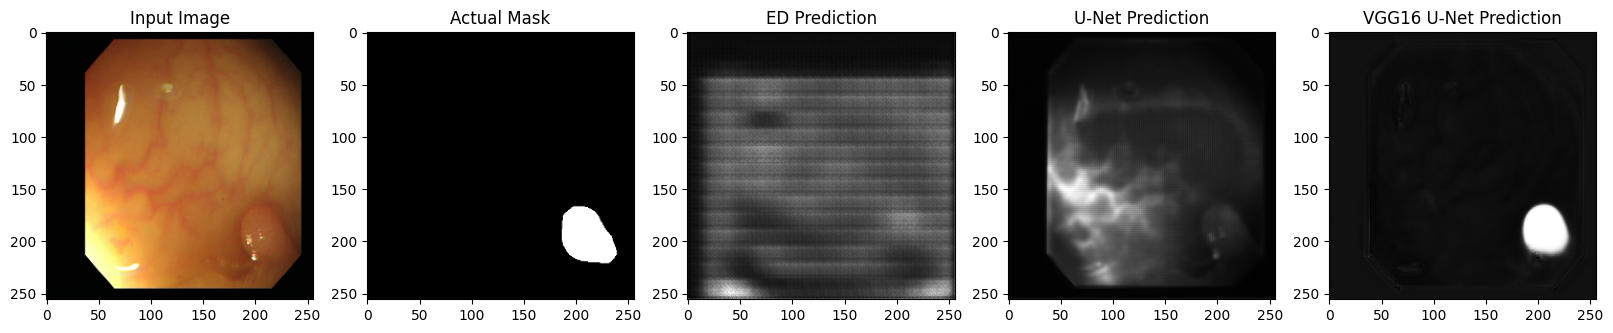

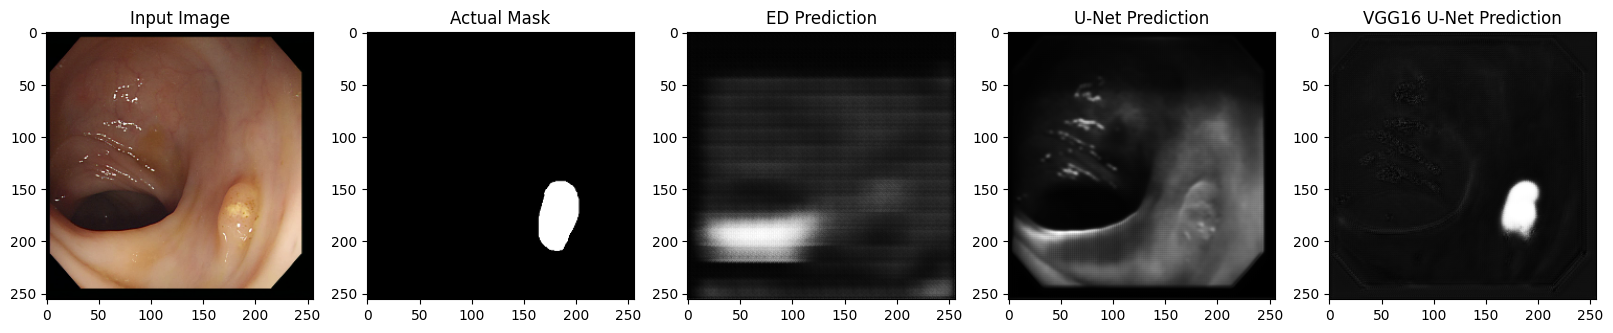

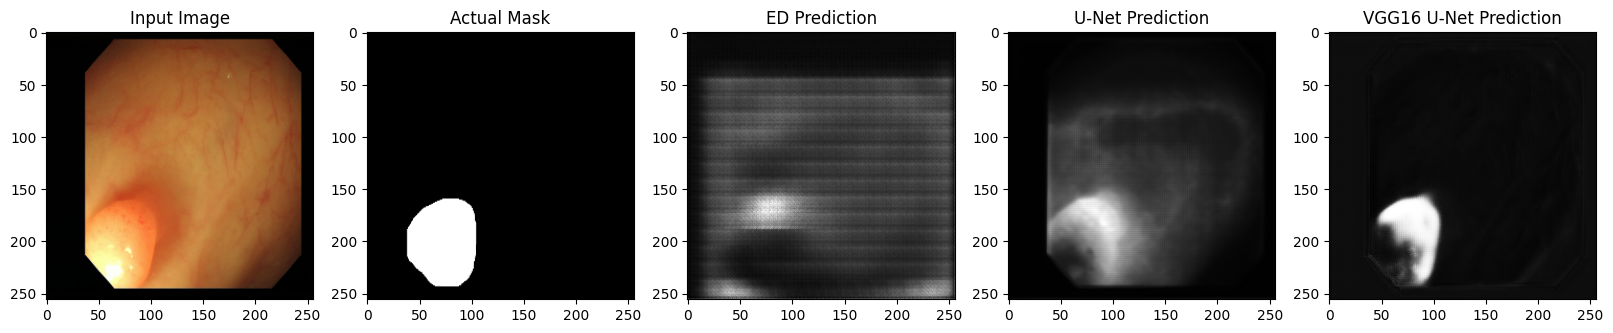

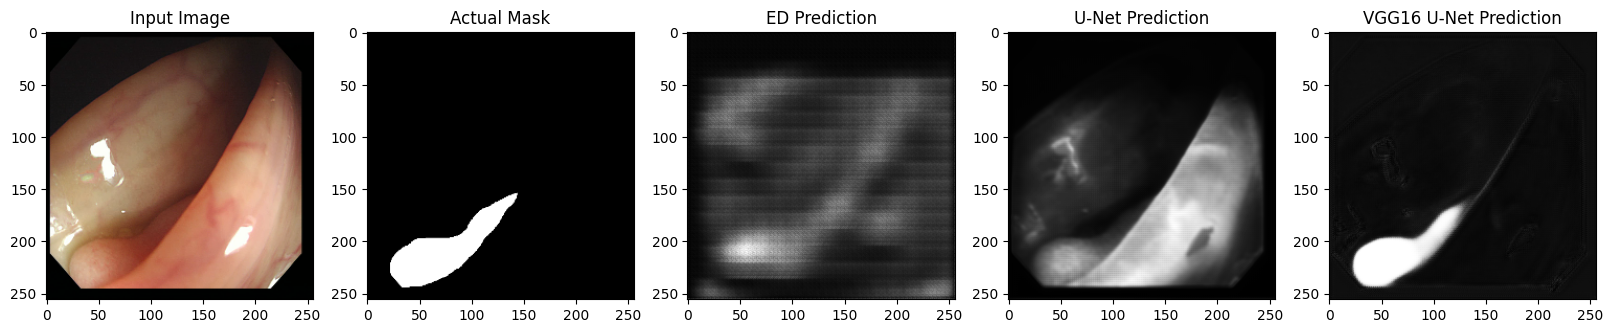

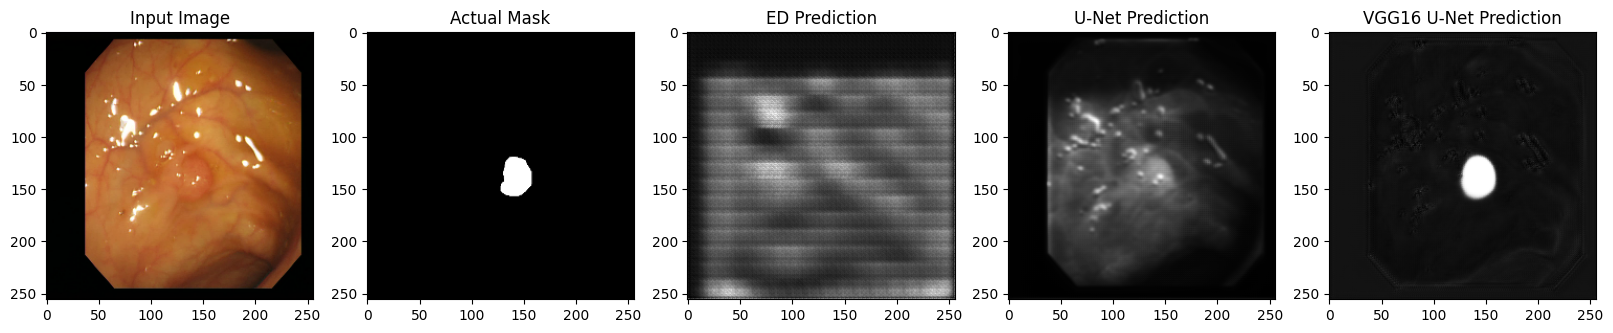

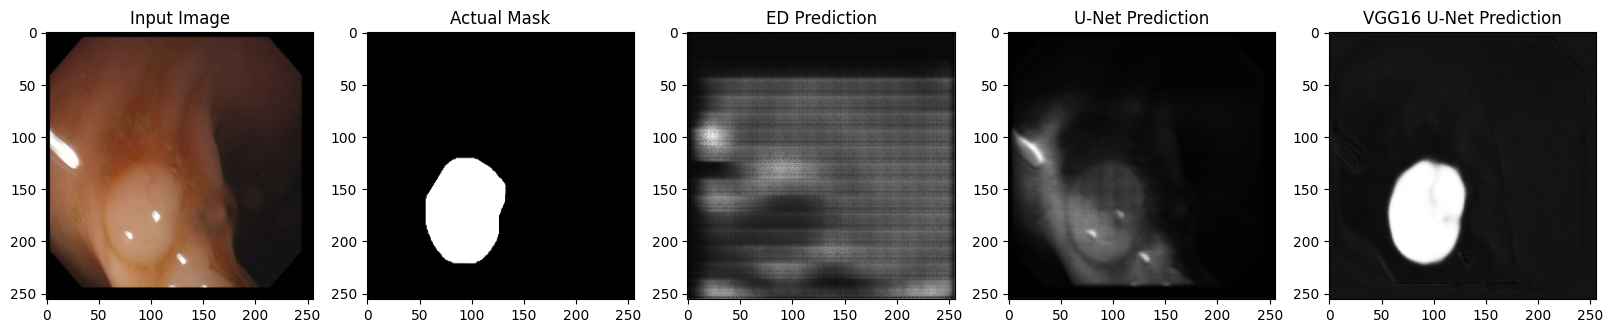

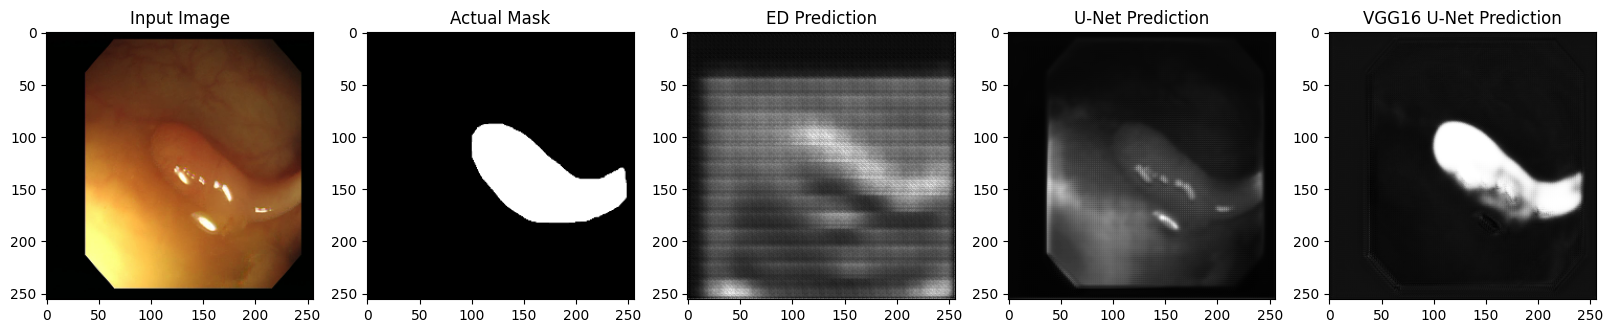

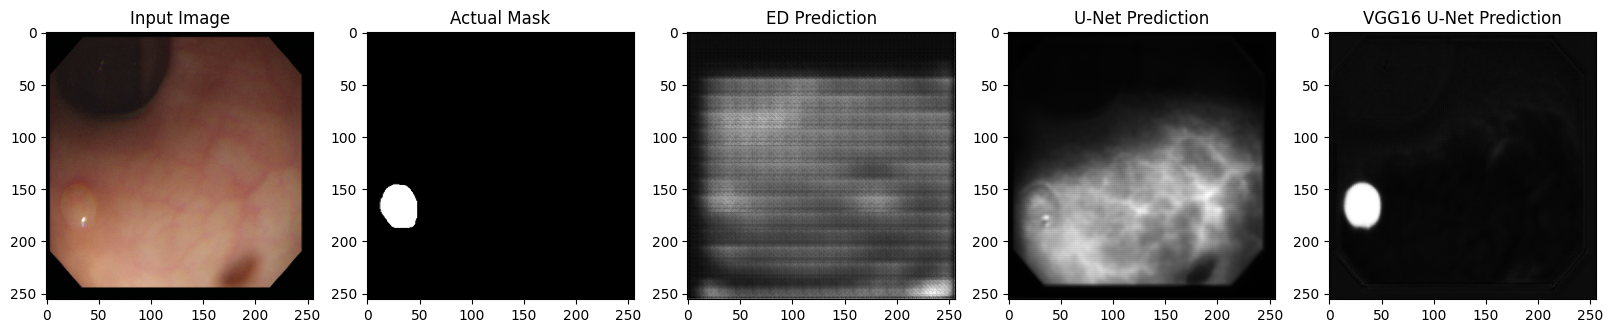

In [59]:
print_images(test_dataset, ed_model, unet_model, model, batch_size=8)

## 회고

- **VGG16**과 같은 ImageNet pretrained 모델을 U-Net의 Encoder로 붙여서 세그멘테이션을 수행해볼 수 있었습니다.

- 이미지 분류와 다르게 세그멘테이션은 훈련 시간 자체가 훨씬 오래 걸렸습니다. 단순히 sigmoid나 softmax로 예측하는 수준이 아니라 라벨 이미지로 저장되어 있는
  마스크 이미지와 최대한 비슷한 마스크 이미지를 생성해내서 그 두 이미지를 비교했을 때 얼마나 일치하는지를 계산해내는 것처럼 이미지 자체를 생성해내는 과정이기 때문에 확실히 분류와는 다르게 데이터셋이 많지 않아도 훨씬 훈련 시간이 오래 걸린다는 걸 체감했습니다.

- 시간이 조금 더 보장되었다면 다른 여러가지 방법들을 시도해보았을 것 같습니다.

  - VGG16 -> EfficientNet

  - 데이터 추가 증강

  - BatchSize 4로 감소

  - Keras Tuner 사용해서 최적의 하이퍼파리미터 찾아서 사용해보기

- 그리고 예측해서 마스크 이미지를 시각화하는 함수는 동일한데, ED_MODEL과 U_NET_MODEL은 마스크를 정확하게 출력하지 못하는데,
  VGG16_U_NET은 정확하게 출력하는 차이를 파악하지 못했습니다.
